# Исследовательский анализ данных банка `Метанпром`

- Данные состоят из двух датасетов:
    - `bank_information.csv` — информация об использовании клиентом услуг банка;
    - `clients_information.csv` — персональная информация клиентов.

Приведём последовательность действий:
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных в столбце Churn с другими данными.
4. Сформулировать выводы по проведённому анализу.


## 1. Загружаем данные

### 1.1 Импортируем необходимые библиотеки

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix


### 1.2 Загружаем датасеты

In [2]:
clients_df = pd.read_csv('/Users/aleksandrrybakov/Downloads/Python/clients_information.csv')
bank_df = pd.read_csv('/Users/aleksandrrybakov/Downloads/Python/bank_information.csv')

Выведем первые 5 строк датасета `bank_df`:

In [3]:
bank_df.head()

,userid,score,Objects,Balance,Products,CreditCard,Loyalty,estimated_salary,Churn
0,15677338,619,2,NaN,1,1,1,101348.88,1
1,15690047,608,1,83807.86,1,0,1,112542.58,0
2,15662040,502,8,159660.80,3,1,0,113931.57,1
3,15744090,699,1,NaN,2,0,0,93826.63,0
4,15780624,850,2,125510.82,1,1,1,79084.10,0


Выведем информацию о датасете:

In [4]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int64  
 2   Objects           10000 non-null  int64  
 3   Balance           6383 non-null   float64
 4   Products          10000 non-null  int64  
 5   CreditCard        10000 non-null  int64  
 6   Loyalty           10000 non-null  int64  
 7   estimated_salary  10000 non-null  float64
 8   Churn             10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.2 KB


- посчитаем количество пустых строк в датасете

In [5]:
bank_df.isna().sum()

userid                 0
score                  0
Objects                0
Balance             3617
Products               0
CreditCard             0
Loyalty                0
estimated_salary       0
Churn                  0
dtype: int64

- **Описание датасета `bank_df`**
    - `userid` — идентификатор клиента;
    - `score` — баллы кредитного скоринга;
    - `Objects` — количество объектов в собственности клиента;
    - `Balance` — баланс на счёте клиента;
    - `Products` — количество продуктов, которыми пользуется клиент;
    - `CreditCard` — есть ли у клиента кредитная карта;
    - `Loyalty` — считается ли клиент активным;
    - `estimated_salary` — заработная плата клиента;
    - `Churn` — ушёл ли клиент из банка.
    
    
Представлена информация об использовании клиентами услуг банка.

**Датасет содержит 10000 строк и 9 столбцов. 7 столбцов типа `int`, 2 столбца типа `float`. В столбце `Balance` содержится 3617 пустый строк**

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов лучше привести к одному виду, например snake case.
- Все представленные данные содержат числовые значения и хранятся в типах данных int64 или float64. Значения в столбцах score, Objects, Products, CreditCard, Loyalty и Churn представлены целыми числами. Часть из них показывает наличие у клиента того или иного признака и содержит значения 1 или 0 — размерность этих данных можно оптимизировать.
- Пропуски содержатся только в столбце Balance. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Выведем первые 5 строк датасета `clients_df`:

In [6]:
clients_df.head()

,userid,LastName,FirstName,Age,Gender,City
0,15677338,Лапина,Евпраксия,42,Ж,Ярославль
1,15690047,Александрова,Акулина,41,Ж,Рыбинск
2,15662040,Лаврентьева,Анна,42,Ж,Ярославль
3,15744090,Никитина,Олимпиада,39,Ж,Ярославль
4,15780624,Некрасова,Майя,43,Ж,Рыбинск


Выведем информацию о датасете:

In [7]:
clients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userid     10000 non-null  int64 
 1   LastName   10000 non-null  object
 2   FirstName  10000 non-null  object
 3   Age        10000 non-null  int64 
 4   Gender     10000 non-null  object
 5   City       10000 non-null  object
dtypes: int64(2), object(4)
memory usage: 468.9+ KB


Датасет содержит 10000 строк, 6 столбцов. 2 столбца типа `int`, 4 столбца типа `object`. В датасете отсутствуют пустые строки

- **Описание датасета `clients_df`**:
    - `userid` — идентификатор клиента;
    - `LastName` — фамилия клиента;
    - `FirstName` — имя клиента;
    - `City` — город обращения в банк;
    - `Gender` — пол;
    - `Age` — возраст.

- Названия столбцов лучше привести к единому виду, например snake case.
- Типы данных соответствуют содержимому. Тип данных для столбца Age можно оптимизировать с понижением размерности. Если в столбце нет аномалий, то маловероятно, что он хранит высокие значения.
- Пропусков на первый взгляд нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
- Значения в столбцах соответствуют описанию.

**Меняем названия, или метки, столбцов датафрейма.
Названия столбцов в двух датафреймах понадобится привести к snake case.**

- Выводим названия столбцов датасета `bank_df`:

In [8]:
bank_df.columns

Index(['userid', 'score', 'Objects', 'Balance', 'Products', 'CreditCard',
       'Loyalty', 'estimated_salary', 'Churn'],
      dtype='object')

Производим замену через словарь:

In [9]:
# Передаём методу rename() словарь с названиями столбцов
bank_df = bank_df.rename(columns={'userid': 'userid',
                                  'Objects': 'objects',
                                  'Balance': 'balance',
                                  'Products': 'products',
                                  'CreditCard': 'credit_card',
                                  'Loyalty': 'loyalty',
                                  'Churn': 'churn'})

Используем функцию для замены в датасете `clients_df`:

In [10]:
# Напишем функцию для корректировки названия столбцов из CamelCase в snake_case
def col_to_snake_case(df):
    """
    Функция приводит названия столбцов из CamelCase в snake_case.
    Пример: столбец FirstName станет first_name.
    В качестве аргументов принимает датафрейм.
    Перебирает столбцы и проверяет каждый столбец.
    Если первый символ является заглавной буквой, то он меняется на прописную.
    Если в названии отыскиваются другие заглавные буквы, перед ними вставляется символ
    подчёркивания, и буква меняется на прописную.
    Функция возвращает исправленный датафрейм.
    """

    for col in df.columns:
        str_bad = col
        if str_bad[0].isupper():
            str_bad = str_bad[0].lower() + str_bad[1:]
        for index_s, item_s in enumerate(str_bad):
            if item_s.isupper():
                str_bad = str_bad[:index_s] + '_' + str_bad[index_s].lower() + str_bad[index_s + 1:]
        df = df.rename(columns={col: str_bad})
    return df

In [11]:
# Применяем функцию col_to_snake_case()
clients_df = col_to_snake_case(clients_df)

Выводим обновленное название полей

In [12]:
bank_df.columns

Index(['userid', 'score', 'objects', 'balance', 'products', 'credit_card',
       'loyalty', 'estimated_salary', 'churn'],
      dtype='object')

In [13]:
clients_df.columns

Index(['userid', 'last_name', 'first_name', 'age', 'gender', 'city'], dtype='object')

Оптимизируем типы данных

In [14]:
# Оптимизируем целочисленный тип данных в датафрейме bank_df
for column in ['score','objects','products',
               'credit_card','loyalty','churn']:
    bank_df[column] = pd.to_numeric(bank_df[column],
                                    downcast='integer')

# Оптимизируем целочисленный тип данных в датафрейме clients_df
clients_df['age'] = pd.to_numeric(clients_df['age'], downcast='integer')

Чтобы разобраться с причиной пропусков, обычно анализируют возможные взаимосвязи пропусков с другими данными. Для этого добавим новый столбец-признак `is_balance`, который укажет на наличие пропуска в столбце `balance`.

In [15]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком в зависимости от наличия данных в другом столбце
def create_is_na(x):
    """
    Функция создаёт новый столбец с бинарным признаком, который указывает
    на наличие данных в столбце. Функция применяется к столбцу после метода isna()
    """
    if x:
        return 0
    return 1

In [16]:
# Создаём столбец is_balance с помощью функции create_is_na
bank_df['is_balance'] = bank_df['balance'].isna().apply(create_is_na)

In [17]:
# Проводим агрегацию данных по полю is_balance
bank_df.groupby('is_balance').agg({
    'score':'mean',
    'objects':'median',
    'products':'median',
    'credit_card':'mean',
    'loyalty':'mean',
    'churn':'mean',
    'estimated_salary':'mean'
})

,score,objects,products,credit_card,loyalty,churn,estimated_salary
is_balance,,,,,,,
0,649.452861,5.0,2.0,0.716616,0.517832,0.138236,98983.559549
1,651.138493,5.0,1.0,0.699201,0.513552,0.240796,100717.352956


Пропуски в столбце balance, скорее всего, неслучайны и могут зависеть от разных факторов, о которых у нас нет информации. Например, от названия продукта.

Проверим уникальные значения

In [18]:
# Проверяем уникальные значения в столбцах
for column in ['objects', 'products', 'credit_card', 'loyalty', 'churn']:
    print(f'Уникальные значения в столбце {column}:')
    print(bank_df[column].sort_values().unique())
    print()

Уникальные значения в столбце objects:
[ 0  1  2  3  4  5  6  7  8  9 10]

Уникальные значения в столбце products:
[1 2 3 4]

Уникальные значения в столбце credit_card:
[0 1]

Уникальные значения в столбце loyalty:
[0 1]

Уникальные значения в столбце churn:
[0 1]



Явные и неявные дубликаты в данных
Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов

In [19]:
# Проверяем полные дубликаты в датафрейме bank_df
bank_df.duplicated().sum()

0

In [20]:
# Проверяем полные дубликаты в датафрейме clients_df
clients_df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк.

Проверим неявные дубликаты — значения по id клиентов должны быть уникальными, то есть каждая строка в данных — уникальный клиент.

In [21]:
# Проверяем неявные дубликаты в датафрейме bank_df
bank_df.duplicated(subset='userid').sum()

0

In [22]:
# Проверяем неявные дубликаты в датафрейме clients_df
clients_df.duplicated(subset='userid').sum()

0

Теперь проверим корректность написания категориальных значений в данных `clients_df`.

In [23]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['gender', 'city']:
    print(f'Уникальные значения в столбце {column}:')
    print(clients_df[column].sort_values().unique())
    print()

Уникальные значения в столбце gender:
['Ж' 'М']

Уникальные значения в столбце city:
['Ростов Великий' 'Рыбинск' 'Ярославль']



В обозначении пола клиента и его города регистрации также нет ошибок.

В результате предобработки данных были выполнены следующие действия:
- Скорректированы названия столбцов — их привели к стилю snake case;
- Изучены пропуски в данных. Пропуски обнаружились в столбце balance и составляют около 36% данных столбца. Учитывая это количество, пропуски могут отражать особенности использования услуг клиентами и не являться ошибкой в данных. Поэтому их оставили как есть.
- Данные проверили на явные и неявные дубликаты — в данных их нет.


# Визуализация

Соединим данные, используя значение параметра `how` по умолчанию — `'inner'`. Это позволит оставить только полные данные по клиентам банка.

In [24]:
# Соединяем данные в единый датафрейм df
df = bank_df.merge(clients_df, on='userid')

Проверим количество данных после присоединения:

In [25]:
# Выводим информацию о датафрейме
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int16  
 2   objects           10000 non-null  int8   
 3   balance           6383 non-null   float64
 4   products          10000 non-null  int8   
 5   credit_card       10000 non-null  int8   
 6   loyalty           10000 non-null  int8   
 7   estimated_salary  10000 non-null  float64
 8   churn             10000 non-null  int8   
 9   is_balance        10000 non-null  int64  
 10  last_name         10000 non-null  object 
 11  first_name        10000 non-null  object 
 12  age               10000 non-null  int8   
 13  gender            10000 non-null  object 
 14  city              10000 non-null  object 
dtypes: float64(2), int16(1), int64(2), int8(6), object(4)
memory usage: 703.2+ KB


Данные соединены, и информация обо всех пользователях сохранилась.

- Сначала разберём столбец objects, который хранит целочисленные дискретные значения.

In [26]:
# Проверяем распределение данных по значениям столбца objects
print('Распределение данных по значениям столбца objects:')
df['objects'].value_counts()

Распределение данных по значениям столбца objects:


objects
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

Результаты показывают, что всего в этом столбце 11 уникальных значений — от 0 до 10, при этом 0 и 10 самые непопулярные. Остальные значения содержат примерно равное количество клиентов — около 1000.

По этим данным можно сделать вывод, что все значения в этом столбце примерно сопоставимы по количеству данных, за исключением двух категорий, где данных в два раза меньше (0 и 10 объектов). Это стоит учитывать при сравнении статистических показателей разных категорий.

Узнаем уникальное количество клиентов по значениям столбца objects:

In [27]:
# Посчитаем количество уникальных клиентов для каждого значения столбца objects
print('Распределение клиентов по значениям столбца objects:')
df.groupby('objects')['userid'].nunique()

Распределение клиентов по значениям столбца objects:


objects
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: userid, dtype: int64

Аналогичным образом проверим данные в столбце products:

In [28]:
# Проверяем распределение данных по значениям столбца products
print('Распределение данных по значениям столбца products:')
df['products'].value_counts()

Распределение данных по значениям столбца products:


products
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Клиенты в основном предпочитают один или два продукта, и общее количество клиентов в этих категориях представлено близкими значениями. А вот тремя и четырьмя продуктами пользуется гораздо меньше людей. Это значит, что клиенты распределены неравномерно между количеством продуктов, и это накладывает свои ограничения на сравнение групп между собой.

Визуализируем распределение в столбце `products`:

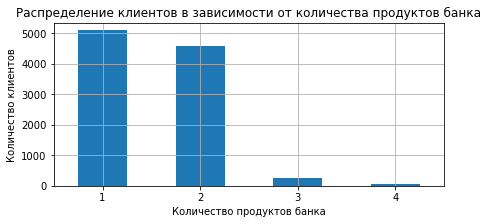

In [29]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['products'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от количества продуктов банка'
)

# Настраиваем оформление графика
plt.xlabel('Количество продуктов банка')
plt.ylabel('Количество клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из категорий по количеству продуктов две значительно преобладают — теперь это хорошо видно.

In [30]:
# Изучаем статистические показатели столбца balance
print('Статистические показатели столбца balance:')
df['balance'].describe()

Статистические показатели столбца balance:


count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: balance, dtype: float64

Можно предположить, что данные баланса имеют распределение, близкое к нормальному. Об этом говорит близость среднего и медианного значений. Однако значение стандартного отклонения довольно высокое — 30095.06, и при среднем 119827.49 это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.

Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха для столбца с балансом.

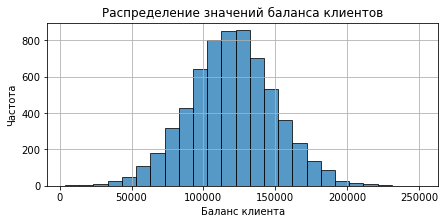

In [31]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['balance'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений баланса клиентов')
plt.xlabel('Баланс клиента')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

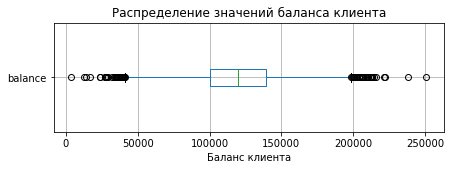

In [32]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='balance', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений баланса клиента')
plt.xlabel('Баланс клиента')

# Выводим график
plt.show()

Распределение данных действительно выглядит нормальным, однако характеризуется широким разбросом и «хвостами» как в левой, так и в правой части гистограммы. Такие низкие и высокие значения можно отнести к выбросам. Однако сами значения, как минимальные, так и максимальные, не выглядят ошибкой, и такой баланс у клиента вполне допустим. Поэтому при анализе данных их оставим.

На гистограмме видно, что распределение значений в столбце score приближается к нормальному, но резко увеличивается количество высоких значений, близких к 850. Такой пик может означать, что 850 — это значение-индикатор, которое отражает пропуски. Например, у таких клиентов может не быть кредитного рейтинга, так как ранее они не оформляли кредиты. Может быть и другое объяснение. Допустим, кредитный рейтинг клиента составляет больше 850. Если значение 850 является максимальным, то всем клиентам с рейтингом выше может присваиваться значение 850.
Проверим эту особенность данных отдельно и изучим распределение данных для значений рейтинга от 840 до 850:

In [33]:
# Проверяем распределение данных по значениям столбца score 840 и выше
print('Распределение данных по значениям столбца score 840 и выше:')
df.loc[df['score'] >= 840]['score'].value_counts()

Распределение данных по значениям столбца score 840 и выше:


score
850    233
841     12
849      8
842      7
844      7
845      6
847      6
846      5
840      5
848      5
843      2
Name: count, dtype: int64

Изучим значения в столбцах с бинарными признаками, применив метод `value_counts()` для каждого столбца в цикле

In [34]:
# Проверяем распределение данных по значениям в столбце
for column in ['credit_card','loyalty','churn']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts(normalize=True))
    print()

Распределение данных по значениям столбца credit_card:
credit_card
1    0.7055
0    0.2945
Name: proportion, dtype: float64

Распределение данных по значениям столбца loyalty:
loyalty
1    0.5151
0    0.4849
Name: proportion, dtype: float64

Распределение данных по значениям столбца churn:
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64



Доля нелояльных клиентов, которые покинули банк, из столбца churn составляет около 20%, а доля клиентов без кредитных карт из столбца credit_card — около 30%. Распределение данных по уникальным значениям столбца loyalty примерно равно — 51% к 49%. Так соотносятся клиенты, которые участвуют в программах лояльности банка, с теми, кто предпочитает в них не участвовать.


Посмотрим на распределение клиентов по значениям в столбцах с полом клиента и городом

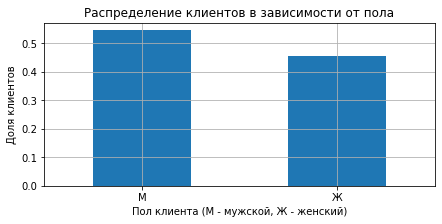

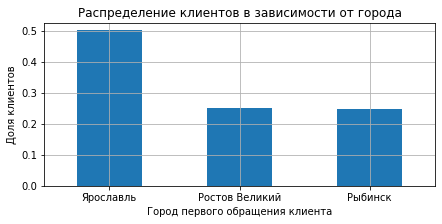

In [35]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['gender'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика — столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от пола'
)

# Настраиваем оформление графика
plt.xlabel('Пол клиента (М - мужской, Ж - женский)')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['city'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от города'
)

# Настраиваем оформление графика
plt.xlabel('Город первого обращения клиента')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Судя по диаграммам, примерно 55% клиентов — мужчины. Половина клиентов представляют Ярославль, а остальная половина — Ростов Великий и Рыбинск примерно поровну.

Считаем корреляцию

In [36]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['objects', 'products', 'balance', 'estimated_salary', 'score',
                         'credit_card', 'loyalty', 'is_balance', 'age',
                         'gender', 'city', 'churn']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной churn')
correlation_matrix.loc[correlation_matrix.index != 'churn'][['churn']].sort_values(by='churn', ascending=False)

interval columns not set, guessing: ['objects', 'products', 'balance', 'estimated_salary', 'score', 'credit_card', 'loyalty', 'is_balance', 'age', 'churn']
Корреляционная матрица с коэффициентом phi_k для переменной churn


,churn
products,0.565084
age,0.487170
loyalty,0.241939
is_balance,0.189997
gender,0.165422
balance,0.116624
score,0.112267
city,0.104511
objects,0.028707
estimated_salary,0.000000


Визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn:

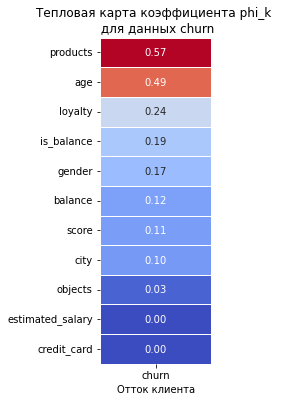

In [37]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'churn'][['churn']].sort_values(by='churn', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных churn')
plt.xlabel('Отток клиента')

# Выводим график
plt.show()

Изучим, существует ли зависимость между уходом клиента из банка и городом первого обращения. Для этого построим столбчатые диаграммы с разделением по признаку churn среди разных городов:

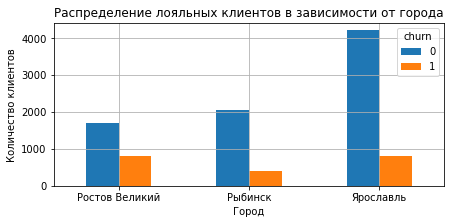

In [38]:
# Построим график столбчатой диаграммы
grouped = df.groupby('city')['churn'].value_counts().unstack(fill_value=0)
grouped.plot(kind='bar',
               title=f'Распределение лояльных клиентов в зависимости от города',
               legend=True,
               ylabel='Количество клиентов',
               xlabel='Город',
               rot=0,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

Рассчитаем среднее значение с помощью `df.groupby('city')['churn'].mean()` и визуализируем результат с помощью столбчатой диаграммы

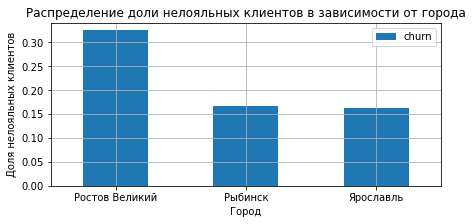

In [39]:
# Построим график столбчатой диаграммы
grouped = df.groupby('city')['churn'].mean()
grouped.plot(kind='bar',
               title=f'Распределение доли нелояльных клиентов в зависимости от города',
               legend=True,
               ylabel='Доля нелояльных клиентов',
               xlabel='Город',
               rot=0,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

Видно, что доля нелояльных клиентов больше всего в Ростове Великом — там она составляет около 33%, а в других городах эта доля равна примерно 16%

Добавим на график линию, которая будет показывать среднее значение. 

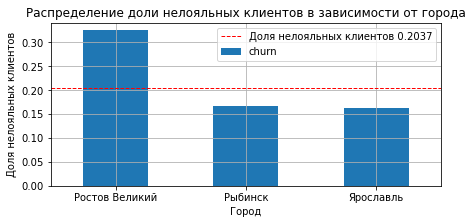

In [40]:
# Строим график столбчатой диаграммы
grouped = df.groupby('city')['churn'].mean()
grouped.plot(kind='bar',
               title=f'Распределение доли нелояльных клиентов в зависимости от города',
               legend=True,
               ylabel='Доля нелояльных клиентов',
               xlabel='Город',
               rot=0,
               figsize=(7, 3))

# Рассчитываем среднее значение по доле нелояльных клиентов
mean_churn_share = df['churn'].mean()

# Наносим на график линию с средним значением доли нелояльных клиентов
plt.axhline(mean_churn_share, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Доля нелояльных клиентов {round(mean_churn_share,4)}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

In [41]:
# Задаём функцию для анализа данных
def plot_bar_plot(df, groupby, value, aggfunc, title, ylabel, xlabel):
    '''
    Функция для анализа распределения метрики по признакам:
    df - датафрейм с данными для анализа;
    groupby - str, название столбца для группировки данных;
    value - str, название столбца, значение которого будет агрегироваться;
    aggfunc - str, функция агрегации, которая используется для расчёта;
    title - str, заголовок графика;
    ylabel - str, подпись по оси Y;
    xlabel - str, подпись по оси X.
    '''
    grouped = df.groupby(groupby).agg({value:aggfunc})
    grouped.plot(kind='bar',
                   title=title,
                   legend=True,
                   ylabel=ylabel,
                   xlabel=xlabel,
                   rot=0,
                   figsize=(7, 3))

    # Рассчитываем общее значение value по всем данным
    mean_churn_share = df.agg({value:aggfunc})[0]

    # Наносим на график линию с значением value по всем данным
    plt.axhline(mean_churn_share, color='red',
                linestyle='--', linewidth=1,
                label=f'Значение по всем данным {round(mean_churn_share,4)}')

    plt.grid()
    plt.legend()
    plt.show()

/var/folders/_x/9hwwkpkx1sq7th5bbrtzzc4w0000gn/T/ipykernel_52207/2450454287.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean_churn_share = df.agg({value:aggfunc})[0]


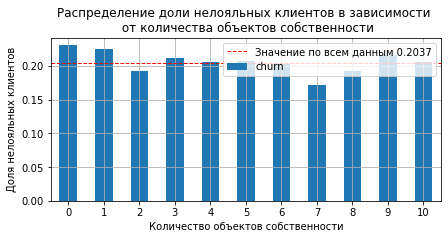

In [42]:
title='Распределение доли нелояльных клиентов в зависимости \n от количества объектов собственности'
xlabel='Количество объектов собственности'
ylabel='Доля нелояльных клиентов'

plot_bar_plot(df, 'objects', 'churn', 'mean', title, ylabel, xlabel)

Теперь перейдём к непрерывным числовым данным и изучим гистограммы распределения возраста в разрезе лояльных и нелояльных клиентов. У клиента может быть два признака лояльности: он либо ушёл из банка, либо нет. Поэтому в matplotlib необходимо построить два графика по разным значениям признака churn. Удобно это сделать в цикле, который будет строить два графика в зависимости от churn. Чтобы не прописывать значение churn вручную, используем метод unique() для определения уникальных значений:

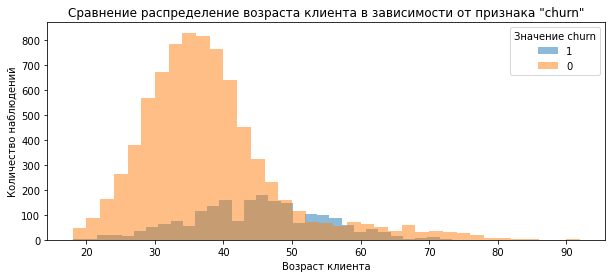

In [43]:
# Строим гистограмму распределения значений возраста
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    df.loc[df['churn'] == i, 'age'].plot(
        kind='hist',
        bins=37,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение распределение возраста клиента в зависимости от признака "churn"')
plt.xlabel('Возраст клиента')
plt.ylabel('Количество наблюдений')
plt.legend(title='Значение churn')
plt.show()

Когда сравниваемые выборки неравномерны по количеству наблюдений, для сравнения их распределений можно построить плотность вероятности. Тогда высота каждого столбца будет нормирована таким образом, что сумма площадей всех столбцов будет равна 1. Таким способом удобнее сравнивать выборки разного размера. Подробно о плотности распределения вы узнаете в одном из следующих спринтов. Сейчас рассмотрим на примере, как её построить и интерпретировать полученные результаты. Для этого можно установить аргумент density=True:

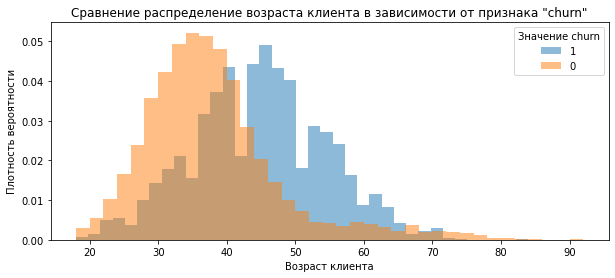

In [44]:
# Строим гистограмму распределения значений возраста
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    df.loc[df['churn'] == i, 'age'].plot(
        kind='hist',
        density=True,
        bins=37,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение распределение возраста клиента в зависимости от признака "churn"')
plt.xlabel('Возраст клиента')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение churn')
plt.show()

Значение параметра bins пропишем как интервал от минимального к максимальному значению с шагом 2: bins=range(min_value, max_value+1, 2). Здесь +1 нужно для того, чтобы увеличить интервал значений, ведь функция range() не использует последнее значение в интервале. При этом важно убедиться, что значения в интервале представлены целыми числами, иначе возникнет ошибка:



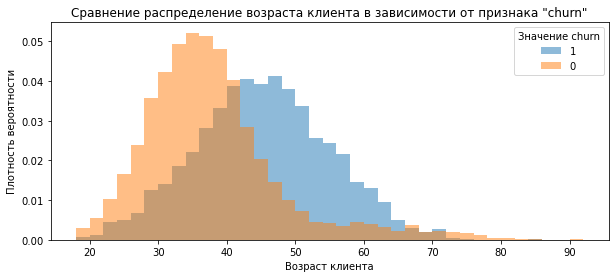

In [45]:
# Строим гистограмму распределения значений возраста
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Находим минимальное и максимальное значения
min_value = df['age'].min()
max_value = df['age'].max()

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    df.loc[df['churn'] == i, 'age'].plot(
        kind='hist',
        density=True,
        bins=range(min_value, max_value+1, 2),
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение распределение возраста клиента в зависимости от признака "churn"')
plt.xlabel('Возраст клиента')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение churn')

plt.show()

Дополнительно вместо гистограммы можно использовать график KDE — оценку функции плотности вероятности для непрерывных данных. KDE представляет гладкую линию, которая показывает вероятность встретить значения в определённом диапазоне. Чем выше линия располагается на графике, тем больше вероятность встретить подобное значение. Сравнение линий KDE двух распределений помогает выявить различия между ними.
Для построения графика KDE можно использовать метод plot() c аргументом kind='kde'. Модифицируем предыдущий код и построим визуализацию KDE:

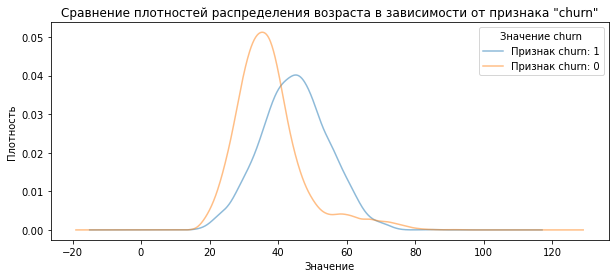

In [46]:
# Строим гистограмму распределения значений возраста
column = 'age'

# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    df.loc[df['churn'] == i, column].plot(
        kind='kde',
        alpha=0.5,
        label=f'Признак churn: {i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение плотностей распределения возраста в зависимости от признака "churn"')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend(title='Значение churn')
plt.show()

Линия KDE для распределения возраста нелояльных клиентов сдвинута вправо по отношению к линии KDE для лояльных клиентов. При этом линия лояльных клиентов выше по значению плотности по сравнению с линией нелояльных клиентов. Это может указывать на разброс значений.
Для более детального анализа данных рассчитаем среднее и медианное значения возраста для лояльных и нелояльных клиентов:

In [47]:
# Рассчитаем среднее и медианное значения возраста для
# лояльных и нелояльных клиентов
df.groupby('churn').agg({'age':['mean','median']})

age       
            mean median
churn                  
0      37.408389   36.0
1      44.837997   45.0

Действительно, видны различия в среднем и медиане для разных клиентов. Значит, возраст клиента можно использовать для дальнейшего изучения причин оттока.

In [48]:
def plot_hist(df, column, groupby, title, xlabel, ylabel, binwidth, kde=False):
    '''
    Функция для визуализации распределения значений с учётом категорий и линией KDE.
    Параметры:
    df - датафрейм с данными для анализа.
    column - str, название столбца, значения которого будут отображаться на графике.
    groupby - str, название столбца, по которому будет производиться группировка данных.
    binwidth - int, ширина корзины для гистограммы.
    title - str, заголовок графика.
    xlabel - str, подпись по оси X.
    ylabel - str, подпись по оси Y.
    kde - наложение графика KDE на гистограмму
    '''

    # Создаём график
    plt.figure(figsize=(7, 3))

    # Находим минимальное и максимальное значения
    min_value = int(df[column].min())
    max_value = round(df[column].max())

    for value in df[groupby].unique():
        # Фильтруем данные по значению столбца churn
        df.loc[df[groupby] == value, column].plot(
            kind='hist',
            density=True,
            bins=range(min_value, max_value+1, binwidth),
            alpha=0.5,
            label=f'{groupby}: {value}',
            legend=True
        )

    for value in df[groupby].unique():
        if kde == True:
            df.loc[df[groupby] == value, column].plot(
                kind='kde',
                label=f'KDE {value}',
            )

    # Настраиваем график
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.xlim(min_value, max_value)

    plt.grid()
    plt.show()

Посмотрим на распределение значений баланса клиента:

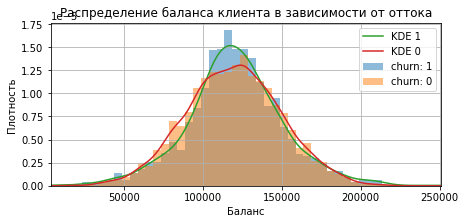

In [49]:
# Изучаем распределение значений баланса клиентов в зависимости от их лояльности
plot_hist(
    df=df,
    column='balance',
    groupby='churn',
    binwidth=5000,
    title='Распределение баланса клиента в зависимости от оттока',
    xlabel='Баланс',
    ylabel='Плотность',
    kde=True
)

Распределение значений баланса лояльных и нелояльных клиентов примерно равно. Предполагаем, что баланс вряд ли играет определяющую роль при уходе клиента из банка.

Посмотрим на взаимосвязь между возрастом и балансом клиента:

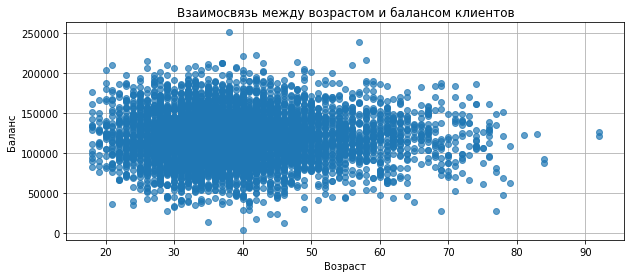

In [51]:
plt.figure(figsize=(10, 4))

# Явно преобразуем pandas-столбцы в numpy-массивы
plt.plot(df['age'].to_numpy(),
         df['balance'].to_numpy(),
         marker='o',
         linestyle='',
         alpha=0.7)

plt.title('Взаимосвязь между возрастом и балансом клиентов')
plt.xlabel('Возраст')
plt.ylabel('Баланс')
plt.grid()
plt.show()

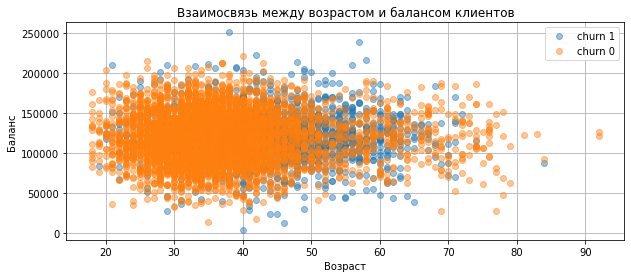

In [53]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    plot_data = df.loc[df['churn'] == i]

    # Строим линейный график
    plt.plot(plot_data['age'].to_numpy(),
             plot_data['balance'].to_numpy(),
             marker='o', # Задаём стиль маркера
             linestyle='', # Делаем линии между точками невидимыми
             label=f'churn {i}',
             alpha=0.45)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между возрастом и балансом клиентов')
plt.xlabel('Возраст')
plt.ylabel('Баланс')
plt.legend()
plt.grid()

# Отображаем график
plt.show()

В ходе исследования проанализировали данные 10000 клиентов банка «Метанпром» из трёх городов. Данные включали персональную информацию клиентов и особенности использования услуг банка. Акцент исследования был на том, чтобы найти взаимосвязи между уходом клиентов и другими факторами. Среди них: возраст и город проживания клиента, текущий баланс и оценочная заработная плата, кредитный рейтинг и наличие кредитной карты, участие в программе лояльности, количество объектов недвижимости и продуктов банка.

Исследовательский анализ данных позволил сформировать профиль клиента банка:
Из 10000 проанализированных клиентов банка половина людей проживает в Ярославле, а остальная половина в Ростове Великом и Рыбинске в равном количестве.
54% клиентов — мужчины, а средний возраст клиентов составляет 39 лет.
Как правило, клиенты банка пользуются 1–2 продуктами. Средний баланс составляет около 120 тыс. рублей, однако у 35% клиентов нет баланса. При этом 70% клиентов оформляют кредитные карты, а 51% участвует в программах лояльности.

Ушедшие, или нелояльные, клиенты составляют 20% от всех клиентов банка.

Результаты показывают, что наибольший процент нелояльных клиентов фиксируется среди клиентов из Ростова Великого (32%). При этом среди женщин также выше процент нелояльных клиентов, чем среди мужчин (25% против 16%). Существенное различие можно отметить среди возрастных групп клиентов: среди нелояльных клиентов преобладают люди возраста 40–50 лет, а среди лояльных — люди возраста 30–40 лет.

Сумма баланса клиента и его оценочная заработная плата не влияют на лояльность. Однако клиенты с неуказанным балансом в целом более лояльны банку. Процент нелояльных клиентов в этом сегменте около 14%, тогда как процент нелояльных клиентов среди тех, для кого указан баланс, возрастает до 24%.

Наличие кредитной карты и значение кредитного рейтинга в целом не влияют на отток клиентов, хотя можно отметить тенденцию, что у большей части лояльных клиентов кредитный рейтинг находится ближе к 700, а среди нелояльных — к 600, хотя средние значения достаточно близки.

Среди клиентов, которые не участвуют в программе лояльности, больше процент ушедших клиентов, чем среди тех, кто в программе лояльности участвует (27% против 14%).

Количество объектов собственности, как правило, не влияет на лояльность клиентов, в отличие от количества продуктов: клиенты с одним продуктом больше склонны к уходу, чем клиенты с двумя продуктами (27% против 8%). Для клиентов с тремя и четырьмя продуктами мало данных, чтобы сделать корректные выводы.

На значение процента клиентов, ушедших в отток, положительно влияют несколько факторов: регион регистрации клиента, его возраст и пол, а также наличие баланса в банке, участие в программе лояльности и количество используемых продуктов.
Среди ушедших клиентов преобладают:
люди из Ростова Великого — это 32% от всех клиентов региона;
женщины — это 25% по сравнению с 16% для клиентов-мужчин;
клиенты возрастом от 40 до 50 лет.
Ушедшие клиенты чаще других имеют баланс в банке, не участвуют в программах лояльности и пользуются одним банковским продуктом.

**Рекомендации**

Можно обратить внимание на удержание клиентов возраста 40–50 лет. Им можно предложить более выгодные условия кредитования или разработать для них специальные банковские продукты и увеличить вовлечённость в программы лояльности.
Дополнительно можно провести более детальную сегментацию, чтобы выделить конкретные группы клиентов.